# MLP do Zero — Experimentos no MNIST

Este notebook documenta o processo de treinamento, validação e comparação de configurações do MLP implementado manualmente com NumPy.

## 1. Instalação e Imports

In [1]:
import sys
import os

# Garante que o pacote mlp seja encontrado
sys.path.insert(0, os.path.abspath('..'))

import numpy as np
import matplotlib.pyplot as plt
import matplotlib
matplotlib.rcParams['figure.dpi'] = 120

from mlp.network import MLP
from mlp.optimizers import SGD, SGDMomentum
from mlp.losses import one_hot

print('NumPy:', np.__version__)
print('Imports OK!')

NumPy: 2.4.6
Imports OK!


## 2. Carregamento e Pré-processamento do MNIST

In [2]:
from mlp.data import load_mnist

X_train, y_train, X_test, y_test = load_mnist(data_dir="../data")
print(f"Treino: {X_train.shape}, rótulos: {y_train.shape}")
print(f"Teste:  {X_test.shape}, rótulos: {y_test.shape}")

Carregando dados...
✓ MNIST carregado: treino (784, 60000), teste (784, 10000)
Treino: (784, 60000), rótulos: (60000,)
Teste:  (784, 10000), rótulos: (10000,)


In [3]:
# Pré-processamento já feito pelo load_mnist:
# - Achatamento: 28x28 → 784
# - Normalização: [0,255] → [0,1]
# - Transposição: (m, 784) → (784, m)
print(f"Pixel range: [{X_train.min():.1f}, {X_train.max():.1f}]")

Pixel range: [0.0, 1.0]


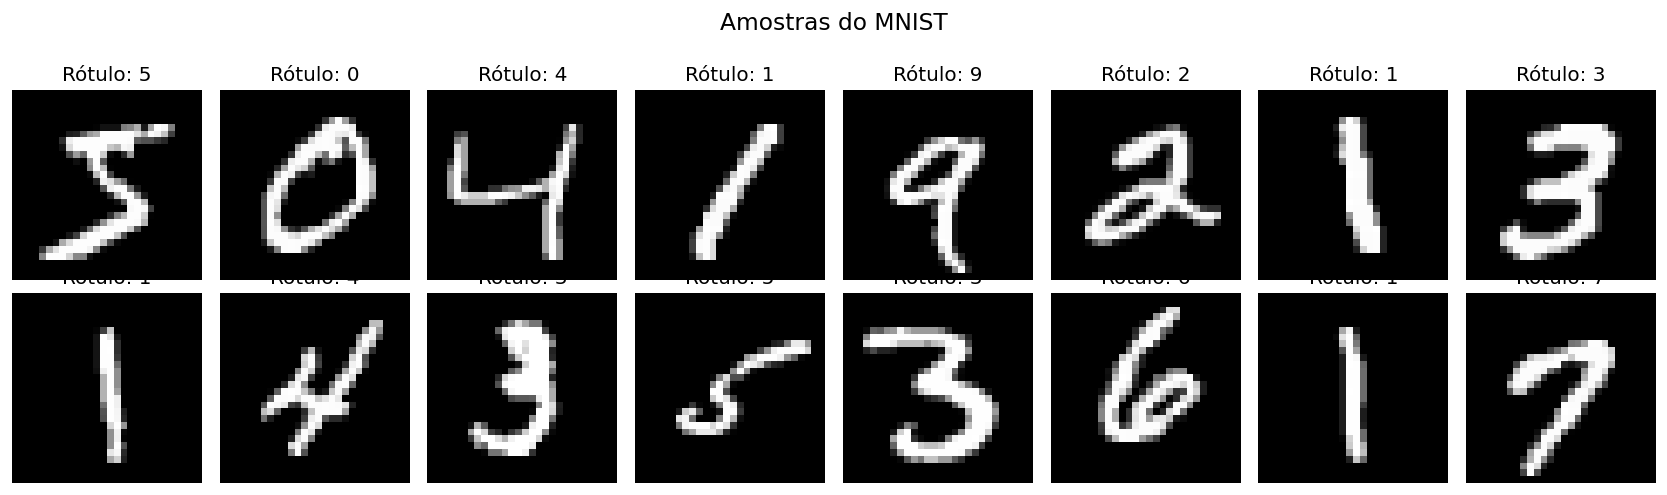

In [4]:
# Visualiza algumas amostras
fig, axes = plt.subplots(2, 8, figsize=(14, 4))
for i, ax in enumerate(axes.flat):
    ax.imshow(X_train[:, i].reshape(28, 28), cmap='gray')
    ax.set_title(f'Rótulo: {y_train[i]}')
    ax.axis('off')
plt.suptitle('Amostras do MNIST', fontsize=14, y=1.02)
plt.tight_layout()
plt.savefig('../results/amostras_mnist.png', bbox_inches='tight')
plt.show()

## 3. Validação Rápida: Gradient Check

In [5]:
# Testa em um subset PEQUENO para verificar gradientes
# Se passar, a implementação está matematicamente correta
X_small = X_train[:, :8]   # apenas 8 exemplos
y_small = y_train[:8]

model_check = MLP(
    layer_sizes=[784, 16, 10],  # rede pequena para gradient check ser rápido
    activation='relu',
    optimizer=SGD(learning_rate=0.01),
    seed=42
)

max_diff = model_check.gradient_check(X_small, y_small, epsilon=1e-5, n_checks=15)
print(f'\nMáxima diferença relativa: {max_diff:.2e}')
assert max_diff < 1e-4, f'Gradient check FALHOU: {max_diff}'
print('✓ Gradientes validados — implementação correta!')


=== Gradient Check (ε=1e-05, 15 parâmetros) ===
  param[0](15, 629) | analítico: 0.014554 | numérico: 0.014554 | diff_rel: 7.35e-10  ✓
  param[0](3, 763) | analítico: 0.000000 | numérico: 0.000000 | diff_rel: 0.00e+00  ✓
  param[3](7, 0) | analítico: 0.111100 | numérico: 0.111100 | diff_rel: 7.76e-11  ✓
  param[1](3, 0) | analítico: 0.030102 | numérico: 0.030102 | diff_rel: 2.04e-10  ✓
  param[1](2, 0) | analítico: -0.014351 | numérico: -0.014351 | diff_rel: 1.11e-10  ✓
  param[0](7, 70) | analítico: 0.000000 | numérico: 0.000000 | diff_rel: 0.00e+00  ✓
  param[0](8, 396) | analítico: -0.068274 | numérico: -0.068274 | diff_rel: 3.47e-11  ✓
  param[2](1, 6) | analítico: 0.002986 | numérico: 0.002986 | diff_rel: 2.74e-10  ✓
  param[3](7, 0) | analítico: 0.111100 | numérico: 0.111100 | diff_rel: 7.76e-11  ✓
  param[2](8, 1) | analítico: 0.046848 | numérico: 0.046848 | diff_rel: 5.72e-12  ✓
  param[1](9, 0) | analítico: 0.022582 | numérico: 0.022582 | diff_rel: 2.75e-10  ✓
  param[1](8, 0

## 4. Experimento A — Configuração Baseline

In [6]:
# Config A: [784 → 256 → 128 → 10], lr=0.01, batch=128, 25 épocas
print('=== Experimento A — Baseline ===')
print('Arquitetura: 784 → 256 → 128 → 10')
print('LR: 0.01 | Batch: 128 | Épocas: 25\n')

model_A = MLP(
    layer_sizes=[784, 256, 128, 10],
    activation='relu',
    optimizer=SGD(learning_rate=0.01),
    seed=42
)

history_A = model_A.train(
    X_train, y_train,
    epochs=25,
    batch_size=128,
    X_val=X_test,
    y_val=y_test,
    verbose=True
)

loss_A, acc_A = model_A.evaluate(X_test, y_test)
print(f'\n✓ Config A — Test Loss: {loss_A:.4f} | Test Acc: {acc_A*100:.2f}%')

=== Experimento A — Baseline ===
Arquitetura: 784 → 256 → 128 → 10
LR: 0.01 | Batch: 128 | Épocas: 25

Época   1/25  train_loss: 0.5569  train_acc: 0.8579  |  val_loss: 0.5311  val_acc: 0.8672  (2.6s)
Época   2/25  train_loss: 0.3926  train_acc: 0.8915  |  val_loss: 0.3710  val_acc: 0.9003  (2.6s)
Época   3/25  train_loss: 0.3346  train_acc: 0.9054  |  val_loss: 0.3166  val_acc: 0.9123  (2.0s)
Época   4/25  train_loss: 0.3017  train_acc: 0.9144  |  val_loss: 0.2887  val_acc: 0.9189  (2.2s)
Época   5/25  train_loss: 0.2770  train_acc: 0.9215  |  val_loss: 0.2643  val_acc: 0.9252  (1.8s)
Época   6/25  train_loss: 0.2610  train_acc: 0.9249  |  val_loss: 0.2506  val_acc: 0.9270  (2.2s)
Época   7/25  train_loss: 0.2427  train_acc: 0.9319  |  val_loss: 0.2345  val_acc: 0.9325  (1.9s)
Época   8/25  train_loss: 0.2303  train_acc: 0.9354  |  val_loss: 0.2246  val_acc: 0.9361  (1.9s)
Época   9/25  train_loss: 0.2180  train_acc: 0.9391  |  val_loss: 0.2136  val_acc: 0.9384  (1.7s)
Época  10/25  t

## 5. Experimento B — Rede Maior com Momentum

In [7]:
# Config B: [784 → 512 → 256 → 128 → 10], Momentum, lr=0.01, batch=64, 30 épocas
print('=== Experimento B — Rede Maior + Momentum ===')
print('Arquitetura: 784 → 512 → 256 → 128 → 10')
print('LR: 0.01 | Momentum: 0.9 | Batch: 64 | Épocas: 30\n')

model_B = MLP(
    layer_sizes=[784, 512, 256, 128, 10],
    activation='relu',
    optimizer=SGDMomentum(learning_rate=0.01, momentum=0.9),
    seed=42
)

history_B = model_B.train(
    X_train, y_train,
    epochs=30,
    batch_size=64,
    X_val=X_test,
    y_val=y_test,
    verbose=True
)

loss_B, acc_B = model_B.evaluate(X_test, y_test)
print(f'\n✓ Config B — Test Loss: {loss_B:.4f} | Test Acc: {acc_B*100:.2f}%')

=== Experimento B — Rede Maior + Momentum ===
Arquitetura: 784 → 512 → 256 → 128 → 10
LR: 0.01 | Momentum: 0.9 | Batch: 64 | Épocas: 30

Época   1/30  train_loss: 0.3204  train_acc: 0.9091  |  val_loss: 0.3088  val_acc: 0.9138  (8.6s)
Época   2/30  train_loss: 0.2397  train_acc: 0.9294  |  val_loss: 0.2324  val_acc: 0.9323  (8.6s)
Época   3/30  train_loss: 0.2065  train_acc: 0.9395  |  val_loss: 0.2078  val_acc: 0.9382  (8.8s)
Época   4/30  train_loss: 0.1702  train_acc: 0.9516  |  val_loss: 0.1745  val_acc: 0.9496  (8.7s)
Época   5/30  train_loss: 0.1492  train_acc: 0.9576  |  val_loss: 0.1591  val_acc: 0.9538  (8.4s)
Época   6/30  train_loss: 0.1335  train_acc: 0.9626  |  val_loss: 0.1464  val_acc: 0.9575  (10.2s)
Época   7/30  train_loss: 0.1200  train_acc: 0.9665  |  val_loss: 0.1334  val_acc: 0.9605  (7.8s)
Época   8/30  train_loss: 0.1069  train_acc: 0.9700  |  val_loss: 0.1244  val_acc: 0.9624  (8.4s)
Época   9/30  train_loss: 0.0993  train_acc: 0.9712  |  val_loss: 0.1184  val_

## 6. Plots — Curvas de Loss e Acurácia

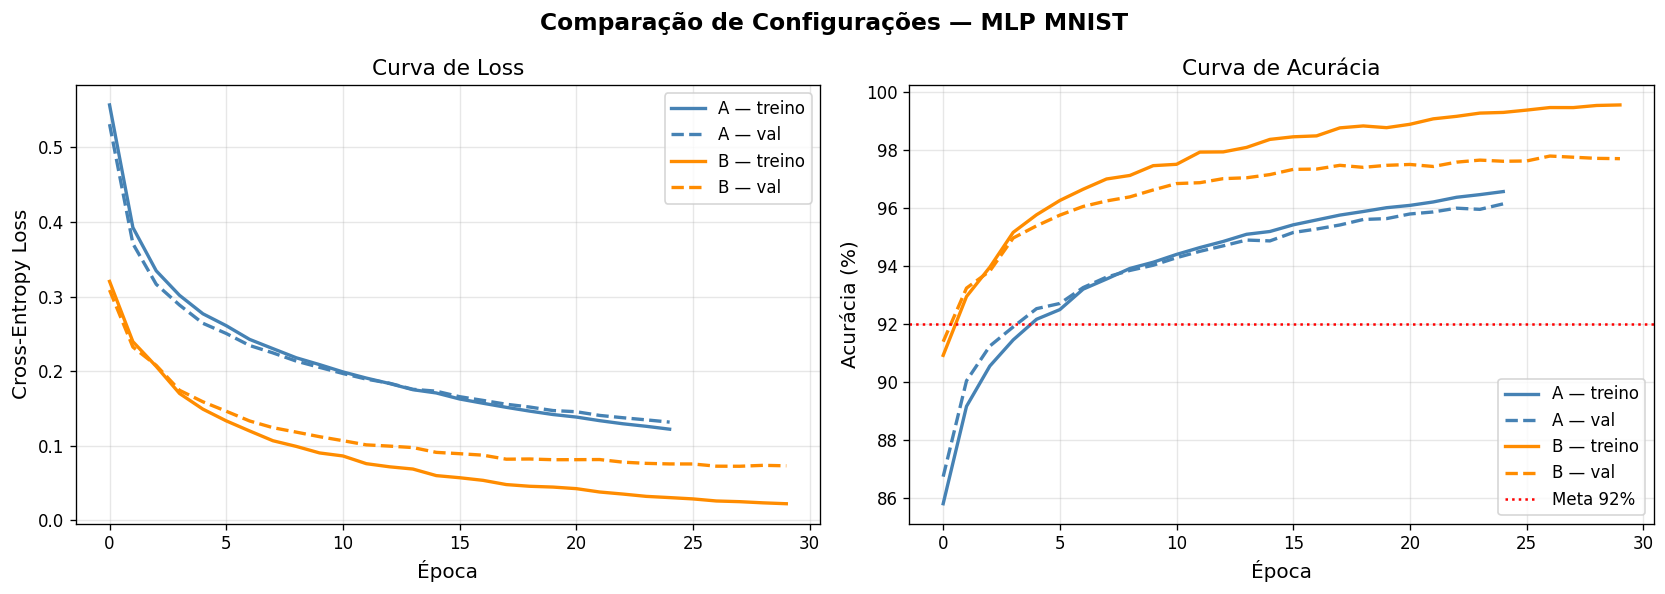

Plot salvo em results/curvas_treino.png


In [8]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# --- Loss ---
ax = axes[0]
ax.plot(history_A['train_loss'], label='A — treino', color='steelblue', linewidth=2)
ax.plot(history_A['val_loss'],   label='A — val',    color='steelblue', linestyle='--', linewidth=2)
ax.plot(history_B['train_loss'], label='B — treino', color='darkorange', linewidth=2)
ax.plot(history_B['val_loss'],   label='B — val',    color='darkorange', linestyle='--', linewidth=2)
ax.set_xlabel('Época', fontsize=12)
ax.set_ylabel('Cross-Entropy Loss', fontsize=12)
ax.set_title('Curva de Loss', fontsize=13)
ax.legend(fontsize=10)
ax.grid(True, alpha=0.3)

# --- Acurácia ---
ax = axes[1]
ax.plot([v*100 for v in history_A['train_acc']], label='A — treino', color='steelblue', linewidth=2)
ax.plot([v*100 for v in history_A['val_acc']],   label='A — val',    color='steelblue', linestyle='--', linewidth=2)
ax.plot([v*100 for v in history_B['train_acc']], label='B — treino', color='darkorange', linewidth=2)
ax.plot([v*100 for v in history_B['val_acc']],   label='B — val',    color='darkorange', linestyle='--', linewidth=2)
ax.axhline(92, color='red', linestyle=':', linewidth=1.5, label='Meta 92%')
ax.set_xlabel('Época', fontsize=12)
ax.set_ylabel('Acurácia (%)', fontsize=12)
ax.set_title('Curva de Acurácia', fontsize=13)
ax.legend(fontsize=10)
ax.grid(True, alpha=0.3)

plt.suptitle('Comparação de Configurações — MLP MNIST', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('../results/curvas_treino.png', bbox_inches='tight', dpi=150)
plt.show()
print('Plot salvo em results/curvas_treino.png')

## 7. Matriz de Confusão

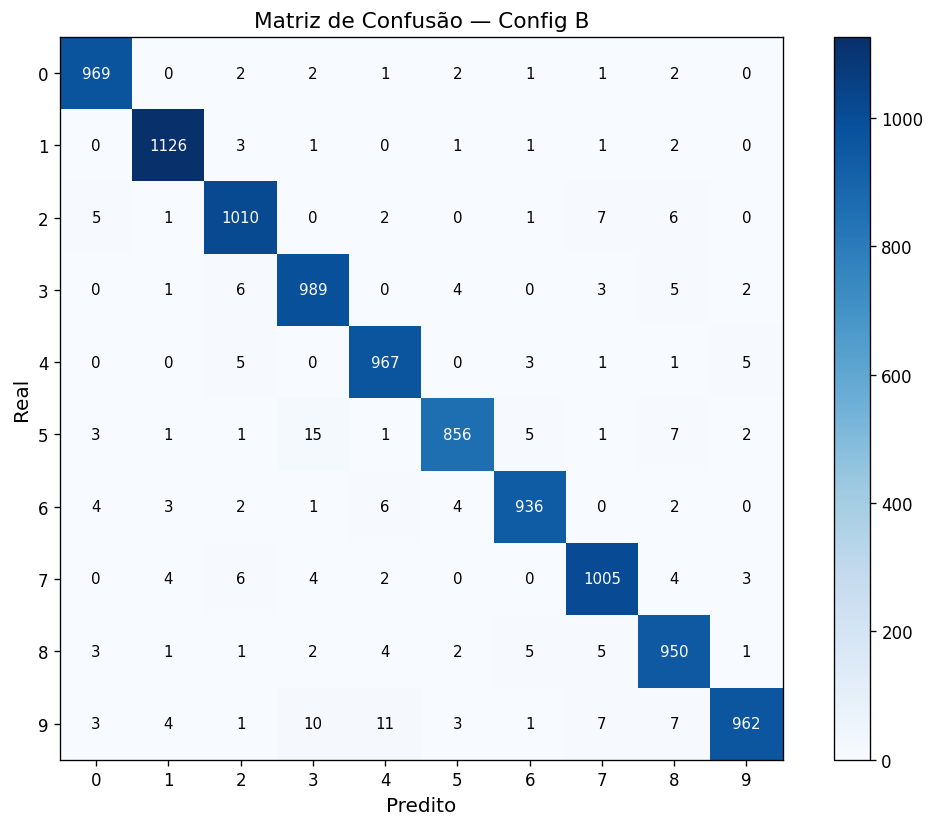

Erros por classe:
  Dígito 0: 11 erros
  Dígito 1: 9 erros
  Dígito 2: 22 erros
  Dígito 3: 21 erros
  Dígito 4: 15 erros
  Dígito 5: 36 erros
  Dígito 6: 22 erros
  Dígito 7: 23 erros
  Dígito 8: 24 erros
  Dígito 9: 47 erros


In [9]:
from sklearn.metrics import confusion_matrix

# Usa o melhor modelo
best_model = model_B if acc_B >= acc_A else model_A
best_name  = 'B' if acc_B >= acc_A else 'A'

y_pred = best_model.predict(X_test)
cm = confusion_matrix(y_test, y_pred)

fig, ax = plt.subplots(figsize=(9, 7))
im = ax.imshow(cm, cmap='Blues')
plt.colorbar(im, ax=ax)

for i in range(10):
    for j in range(10):
        color = 'white' if cm[i, j] > cm.max() / 2 else 'black'
        ax.text(j, i, str(cm[i, j]), ha='center', va='center', color=color, fontsize=9)

ax.set_xticks(range(10))
ax.set_yticks(range(10))
ax.set_xlabel('Predito', fontsize=12)
ax.set_ylabel('Real', fontsize=12)
ax.set_title(f'Matriz de Confusão — Config {best_name}', fontsize=13)
plt.tight_layout()
plt.savefig('../results/confusion_matrix.png', bbox_inches='tight', dpi=150)
plt.show()

# Identifica as classes com mais erros
errors_per_class = cm.sum(axis=1) - np.diag(cm)
print('Erros por classe:')
for c, e in enumerate(errors_per_class):
    print(f'  Dígito {c}: {e} erros')

## 8. Tabela Comparativa Final

In [10]:
results = [
    {
        'Config': 'A — Baseline',
        'Arquitetura': '784→256→128→10',
        'Otimizador': 'SGD',
        'LR': 0.01,
        'Batch': 128,
        'Épocas': 25,
        'Test Acc (%)': f'{acc_A*100:.2f}',
        'Test Loss': f'{loss_A:.4f}',
    },
    {
        'Config': 'B — Momentum',
        'Arquitetura': '784→512→256→128→10',
        'Otimizador': 'SGD+Momentum(0.9)',
        'LR': 0.01,
        'Batch': 64,
        'Épocas': 30,
        'Test Acc (%)': f'{acc_B*100:.2f}',
        'Test Loss': f'{loss_B:.4f}',
    },
]

print('\n' + '='*80)
print('TABELA COMPARATIVA DE EXPERIMENTOS')
print('='*80)
headers = list(results[0].keys())
col_w = 22
print(' | '.join(h.ljust(col_w) for h in headers))
print('-'*(col_w * len(headers) + 3 * (len(headers)-1)))
for r in results:
    print(' | '.join(str(r[h]).ljust(col_w) for h in headers))
print('='*80)
print(f'\nMeta: ≥ 92% de acurácia no teste')
print(f'Config A: {acc_A*100:.2f}%  {"✓" if acc_A >= 0.92 else "✗"}')
print(f'Config B: {acc_B*100:.2f}%  {"✓" if acc_B >= 0.92 else "✗"}')


TABELA COMPARATIVA DE EXPERIMENTOS
Config                 | Arquitetura            | Otimizador             | LR                     | Batch                  | Épocas                 | Test Acc (%)           | Test Loss             
-----------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------
A — Baseline           | 784→256→128→10         | SGD                    | 0.01                   | 128                    | 25                     | 96.14                  | 0.1318                
B — Momentum           | 784→512→256→128→10     | SGD+Momentum(0.9)      | 0.01                   | 64                     | 30                     | 97.70                  | 0.0732                

Meta: ≥ 92% de acurácia no teste
Config A: 96.14%  ✓
Config B: 97.70%  ✓


## 9. Visualização de Erros

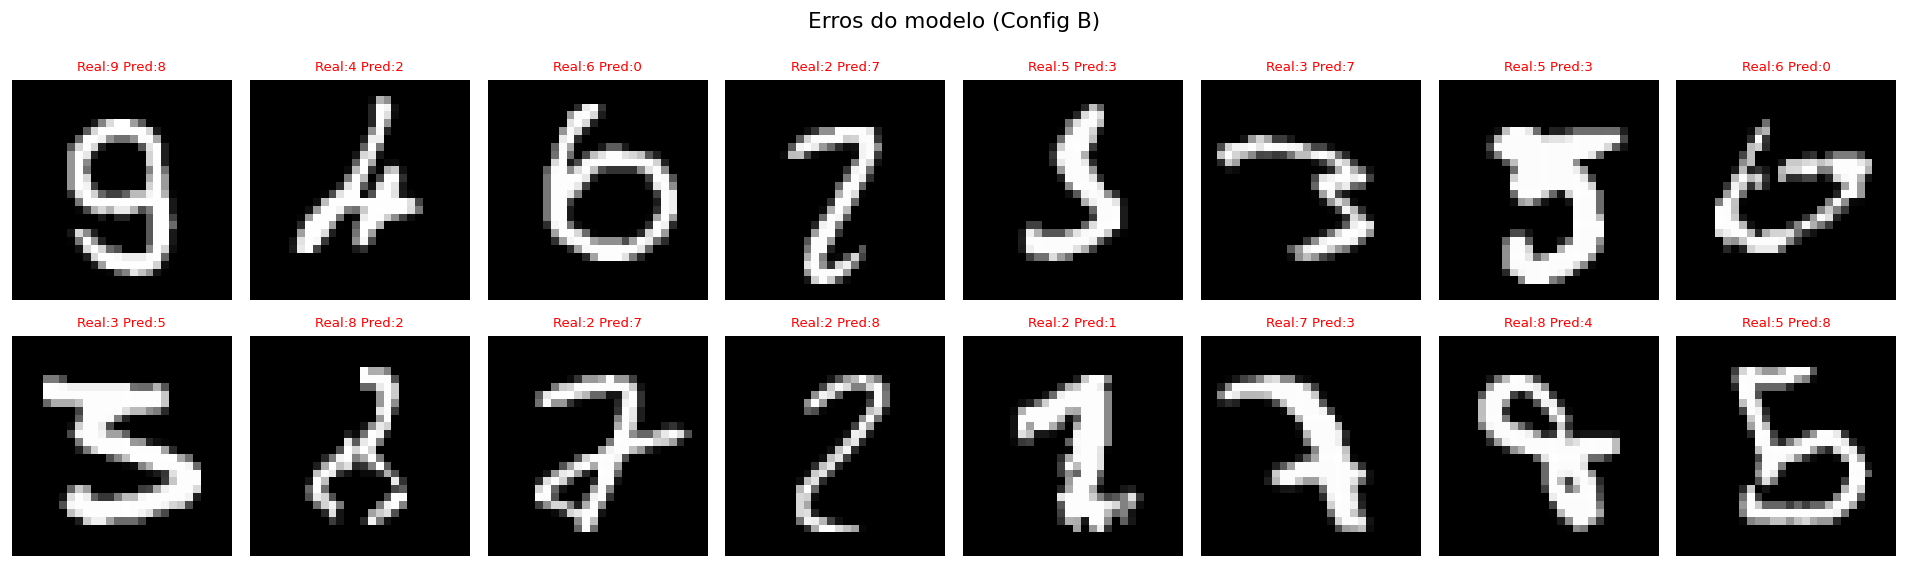

In [11]:
# Exemplos que o melhor modelo errou
y_pred_best = best_model.predict(X_test)
wrong_idx = np.where(y_pred_best != y_test)[0][:16]

fig, axes = plt.subplots(2, 8, figsize=(16, 5))
for i, (ax, idx) in enumerate(zip(axes.flat, wrong_idx)):
    ax.imshow(X_test[:, idx].reshape(28, 28), cmap='gray')
    ax.set_title(f'Real:{y_test[idx]} Pred:{y_pred_best[idx]}', fontsize=8, color='red')
    ax.axis('off')
plt.suptitle(f'Erros do modelo (Config {best_name})', fontsize=13)
plt.tight_layout()
plt.savefig('../results/exemplos_erro.png', bbox_inches='tight', dpi=150)
plt.show()